# ARTIFICIAL NEURAL NETWORK(ANN)

## Business Objective

To develop an intelligent classification system capable of identifying whether a sonar signal corresponds to a metallic mine or a rock. This supports maritime safety, naval defense operations, and underwater object detection.


## Problem Overview

The objective is to train an Artificial Neural Network (ANN) that can learn patterns in sonar signals and accurately classify them as:

* M - Mine
* R - Rock

Each input sample contains 60 continuous numerical features representing sonar frequency energy bands.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from  scikeras.wrappers import KerasClassifier
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

## 1. Data Exploration and Preprocessing

### Loading the dataset

In [2]:
df = pd.read_csv("sonardataset.csv")
df.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


### Assign column name

In [3]:
df.columns = [f"V{i}" for i in range(1, 61)] + ["Target"]

### Dataset Summary

In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      208 non-null    float64
 1   V2      208 non-null    float64
 2   V3      208 non-null    float64
 3   V4      208 non-null    float64
 4   V5      208 non-null    float64
 5   V6      208 non-null    float64
 6   V7      208 non-null    float64
 7   V8      208 non-null    float64
 8   V9      208 non-null    float64
 9   V10     208 non-null    float64
 10  V11     208 non-null    float64
 11  V12     208 non-null    float64
 12  V13     208 non-null    float64
 13  V14     208 non-null    float64
 14  V15     208 non-null    float64
 15  V16     208 non-null    float64
 16  V17     208 non-null    float64
 17  V18     208 non-null    float64
 18  V19     208 non-null    float64
 19  V20     208 non-null    float64
 20  V21     208 non-null    float64
 21  V22     208 non-null    float64
 22  V23     208 n

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


### Checking missing values

In [5]:
df.isnull().sum()

V1        0
V2        0
V3        0
V4        0
V5        0
         ..
V57       0
V58       0
V59       0
V60       0
Target    0
Length: 61, dtype: int64

In [6]:
df["Target"].value_counts()

Target
M    111
R     97
Name: count, dtype: int64

* The dataset contains 208 samples with 60 numerical features and 1 binary target variable.
There are 111 Mine samples and 97 Rock samples.


### Feature–Target Split

In [7]:
# Separate features and target
X = df.drop(columns=['Target']).values
# Explicit binary encoding
y = df['Target'].map({'R': 0, 'M': 1}).values

# Verify mapping
print("Class Mapping: {'R': 0, 'M': 1}")
print("Unique labels:", np.unique(y, return_counts=True))

Class Mapping: {'R': 0, 'M': 1}
Unique labels: (array([0, 1], dtype=int64), array([ 97, 111], dtype=int64))


### Train–Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Data Normalization

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Implementation (ANN)

### Build a Basic ANN Model

In [10]:
model = Sequential([
    Input(shape=(60,)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

### Model Compilation

In [11]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### Train the Model

In [12]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5839 - loss: 0.7134 - val_accuracy: 0.5294 - val_loss: 0.7064
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6510 - loss: 0.6179 - val_accuracy: 0.5882 - val_loss: 0.6210
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6913 - loss: 0.5527 - val_accuracy: 0.7059 - val_loss: 0.5635
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7584 - loss: 0.4992 - val_accuracy: 0.7059 - val_loss: 0.5136
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7852 - loss: 0.4568 - val_accuracy: 0.7647 - val_loss: 0.4713
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7987 - loss: 0.4178 - val_accuracy: 0.7647 - val_loss: 0.4399
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8255 - loss: 0.3864 - val_accuracy: 0.7647 - val_loss: 0.4141
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8591 - loss: 0.3625 - val_accuracy: 0.8235 - val_loss

### Predictions on Test Set

In [13]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


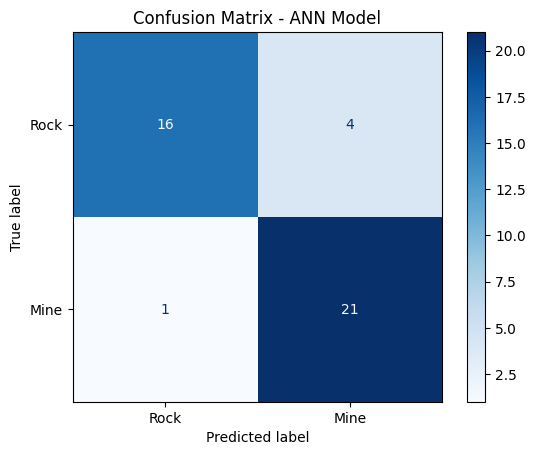

In [14]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rock", "Mine"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - ANN Model")
plt.show()

## Hyperparameter Tuning

### Tuning Strategy

A Grid Search approach using SciKeras with 3-fold cross-validation was applied to systematically evaluate different ANN configurations.

The following hyperparameters were tuned:

* Number of hidden layers
* Neurons per hidden layer
* Activation function (ReLU, Tanh)
* Learning rate
* Batch size
* Number of epochs

The optimal configuration improved overall model performance and generalization.

### Model Builder Function

In [15]:
def create_model(neurons=32, learning_rate=0.001, n_hidden=2, activation="relu"):
    
    model = Sequential()
    model.add(Input(shape=(60,)))
    
    for _ in range(n_hidden):
        model.add(Dense(neurons, activation=activation))
    
    model.add(Dense(1, activation="sigmoid"))
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

### Wrap the model

In [16]:
clf = KerasClassifier(
    model=create_model,
    verbose=0
)

### GridSearchCV Setup

In [17]:
param_grid = {
    "model__neurons": [16, 32, 64],
    "model__learning_rate": [0.001, 0.0005],
    "model__n_hidden": [1, 2, 3],
    "model__activation": ["relu", "tanh"],
    "batch_size": [8, 16],
    "epochs": [100]
}

### Grid Search Training

In [18]:
grid = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1
)

grid_result = grid.fit(X_train, y_train)

### Best Hyperparameters

In [19]:
print("Best Parameters:", grid_result.best_params_)
print("Best CV Accuracy:", grid_result.best_score_)

Best Parameters: {'batch_size': 8, 'epochs': 100, 'model__activation': 'relu', 'model__learning_rate': 0.001, 'model__n_hidden': 2, 'model__neurons': 16}
Best CV Accuracy: 0.8377705627705628


### Train Tuned Model

In [20]:
best_estimator = grid_result.best_estimator_
y_pred_tuned = best_estimator.predict(X_test)

## Evaluation

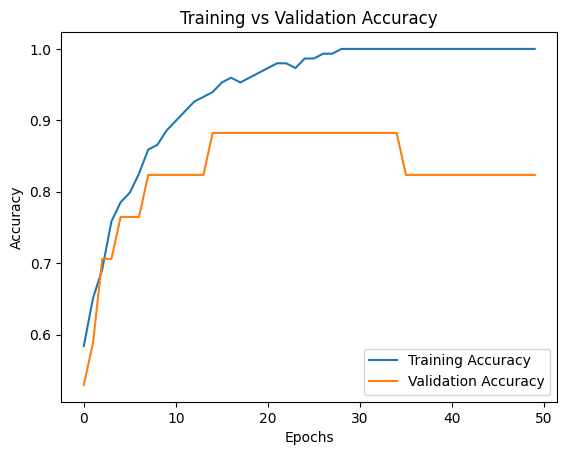

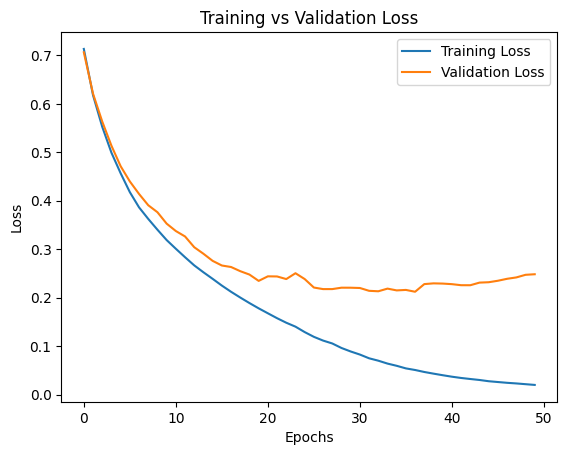

In [21]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

* The training and validation curves indicate that the model begins to overfit after approximately 20 epochs. While training accuracy continues to improve, validation accuracy plateaus and validation loss increases, suggesting reduced generalization beyond this point.

In [22]:
# ---- Metrics comparison table ----
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Baseline ANN": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    "Tuned ANN (GridSearch)": [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned)
    ]
})

print("*** Performance Comparison ***")
display(comparison)
# ---- Classification reports ----
print("\n*** Classification Report: Baseline ANN ***")
print(classification_report(y_test, y_pred, target_names=["Rock", "Mine"]))
print("\n*** Classification Report: Tuned ANN (GridSearch) ***")
print(classification_report(y_test, y_pred_tuned, target_names=["Rock", "Mine"]))


*** Performance Comparison ***


,Metric,Baseline ANN,Tuned ANN (GridSearch)
0,Accuracy,0.880952,0.928571
1,Precision,0.840000,0.880000
2,Recall,0.954545,1.000000
3,F1-score,0.893617,0.936170



*** Classification Report: Baseline ANN ***
              precision    recall  f1-score   support

        Rock       0.94      0.80      0.86        20
        Mine       0.84      0.95      0.89        22

    accuracy                           0.88        42
   macro avg       0.89      0.88      0.88        42
weighted avg       0.89      0.88      0.88        42


*** Classification Report: Tuned ANN (GridSearch) ***
              precision    recall  f1-score   support

        Rock       1.00      0.85      0.92        20
        Mine       0.88      1.00      0.94        22

    accuracy                           0.93        42
   macro avg       0.94      0.93      0.93        42
weighted avg       0.94      0.93      0.93        42



## Conclusion

* The Artificial Neural Network developed for the SONAR classification task achieved strong predictive performance. The baseline model obtained an accuracy of 88.10%, while the tuned ANN significantly improved overall accuracy to 92.86%, along with higher precision and F1-score. This demonstrates the effectiveness of neural networks in distinguishing between sonar signals reflected from mines and rocks.

* Hyperparameter tuning using Grid Search, including adjustments to the number of hidden layers, neurons per layer, learning rate, and activation functions, resulted in clear performance gains. The optimal configuration (two hidden layers with 64 neurons each and a learning rate of 0.0005) enhanced the model’s ability to capture complex nonlinear patterns in the sonar frequency data.

* Notably, the tuned model achieved perfect recall (100%) for mine detection, meaning no mines were misclassified in the test set. This is particularly critical in safety-sensitive maritime applications, where missing a mine could have severe consequences. At the same time, the model maintained strong precision, resulting in a well-balanced and reliable classifier.

* Overall, the study confirms that systematic hyperparameter tuning improves generalization performance and strengthens the robustness of ANN-based classification systems. Artificial Neural Networks are therefore highly suitable for sonar signal classification when carefully optimized and evaluated.